In [2]:
!pip install -q riskfolio-lib==6.2.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 972.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.1 MB/s eta 0:00:00


In [4]:
# ============================================================
# BLACK-LITTERMAN PORTFOLIO
# INDIAN LARGE-CAP EQUITIES
# Riskfolio-Lib 6.2.3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import riskfolio as rp


# ============================================================
# 1. ASSET UNIVERSE
# ============================================================

tickers = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "BHARTIARTL.NS",
    "TCS.NS",
    "INFY.NS",
    "SBIN.NS",
    "ITC.NS",
    "LT.NS",
    "MARUTI.NS"
]


# ============================================================
# 2. DOWNLOAD PRICE DATA
# ============================================================

prices = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-08-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna(axis=1, how="any")

tickers = prices.columns.tolist()

print("Assets used:")
print(tickers)


# ============================================================
# 3. DAILY RETURNS
# ============================================================

returns = prices.pct_change().dropna()

print("\nReturn observations:", len(returns))


# ============================================================
# 4. MARKET-CAP WEIGHTS
# ============================================================
#
# These are NORMALIZED approximate relative market-cap
# inputs for the initial model.
#
# For the final publishable version we can replace these
# with historical market-cap data.
# ============================================================

market_caps = pd.Series({

    "RELIANCE.NS": 18.0,
    "HDFCBANK.NS": 14.0,
    "ICICIBANK.NS": 10.0,
    "BHARTIARTL.NS": 12.0,
    "TCS.NS": 13.0,
    "INFY.NS": 7.0,
    "SBIN.NS": 7.0,
    "ITC.NS": 6.0,
    "LT.NS": 5.0,
    "MARUTI.NS": 4.0

})

market_caps = market_caps.reindex(tickers)

w_market = (
    market_caps /
    market_caps.sum()
)

print("\nMarket Weights:")

display(
    w_market.to_frame(
        "Market Weight"
    )
)


# ============================================================
# 5. CURRENT ANALYST VIEWS
# ============================================================
#
# 12-month target-return views.
#
# Bharti Airtel : 20.64%
# SBI           : 18.51%
# ITC           : 18.82%
#
# Other values are explicit research inputs and should be
# treated as model views, NOT guaranteed returns.
# ============================================================

views = pd.Series({

    "RELIANCE.NS": 0.15,

    "HDFCBANK.NS": 0.20,

    "ICICIBANK.NS": 0.18,

    "BHARTIARTL.NS": 0.2064,

    "TCS.NS": 0.05,

    "INFY.NS": 0.04,

    "SBIN.NS": 0.1851,

    "ITC.NS": 0.1882,

    "LT.NS": 0.20,

    "MARUTI.NS": 0.1557
})

views = views.reindex(tickers)

print("\nAnalyst / Research Views:")

display(
    views.to_frame(
        "12M View"
    )
)


# ============================================================
# 6. VIEW MATRIX
# ============================================================
#
# Absolute views:
#
# Expected return of each individual stock.
#
# Therefore P = Identity Matrix.
# ============================================================

P = np.eye(
    len(tickers)
)

Q = views.values.reshape(
    -1,
    1
)

print("\nP shape:", P.shape)
print("Q shape:", Q.shape)


# ============================================================
# 7. COVARIANCE MATRIX
# ============================================================

Sigma = returns.cov() * 252


# ============================================================
# 8. RISK AVERSION
# ============================================================

delta = 2.5


# ============================================================
# 9. TAU
# ============================================================

tau = 0.05


# ============================================================
# 10. MARKET EQUILIBRIUM RETURNS
# ============================================================

w = w_market.values.reshape(
    -1,
    1
)

pi = (
    delta *
    Sigma.values @
    w
)


# ============================================================
# 11. VIEW UNCERTAINTY
# ============================================================

Omega = np.diag(
    np.diag(
        tau *
        P @
        Sigma.values @
        P.T
    )
)


# ============================================================
# 12. BLACK-LITTERMAN POSTERIOR
# ============================================================

tau_sigma = (
    tau *
    Sigma.values
)

inv_tau_sigma = np.linalg.inv(
    tau_sigma
)

inv_omega = np.linalg.inv(
    Omega
)


posterior_cov = np.linalg.inv(
    inv_tau_sigma +
    P.T @
    inv_omega @
    P
)


mu_bl = posterior_cov @ (
    inv_tau_sigma @ pi +
    P.T @
    inv_omega @
    Q
)


# ============================================================
# 13. POSTERIOR RETURN SERIES
# ============================================================

mu_bl = pd.Series(
    mu_bl.flatten(),
    index=tickers,
    name="BL Posterior Return"
)


print("\nBlack-Litterman Posterior Returns:")

display(
    mu_bl.sort_values(
        ascending=False
    ).to_frame()
)


# ============================================================
# 14. CREATE RISKFOLIO PORTFOLIO
# ============================================================

port = rp.Portfolio(
    returns=returns
)


# ============================================================
# 15. SET BL EXPECTED RETURNS
# ============================================================

port.mu = mu_bl


# ============================================================
# 16. BLACK-LITTERMAN PORTFOLIO OPTIMIZATION
# ============================================================

w_bl = port.optimization(
    model="Classic",
    rm="MV",
    obj="Sharpe"
)


# ============================================================
# 17. FINAL PORTFOLIO WEIGHTS
# ============================================================

print("\nBLACK-LITTERMAN PORTFOLIO WEIGHTS")

display(
    w_bl.sort_values(
        by=w_bl.columns[0],
        ascending=False
    )
)


# ============================================================
# 18. WEIGHT PLOT
# ============================================================

w_bl.iloc[:, 0].plot(
    kind="bar",
    figsize=(12, 5),
    title="Black-Litterman Portfolio Weights"
)

plt.ylabel("Portfolio Weight")
plt.xlabel("Asset")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

Assets used:
['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'LT.NS', 'RELIANCE.NS', 'SBIN.NS', 'TCS.NS']

Return observations: 2120

Market Weights:


,Market Weight
HDFCBANK.NS,0.1750
ICICIBANK.NS,0.1250
INFY.NS,0.0875
ITC.NS,0.0750
LT.NS,0.0625
RELIANCE.NS,0.2250
SBIN.NS,0.0875
TCS.NS,0.1625



Analyst / Research Views:


,12M View
HDFCBANK.NS,0.2000
ICICIBANK.NS,0.1800
INFY.NS,0.0400
ITC.NS,0.1882
LT.NS,0.2000
RELIANCE.NS,0.1500
SBIN.NS,0.1851
TCS.NS,0.0500



P shape: (8, 8)
Q shape: (8, 1)

Black-Litterman Posterior Returns:


,BL Posterior Return
SBIN.NS,0.178287
ICICIBANK.NS,0.171836
LT.NS,0.160555
HDFCBANK.NS,0.155263
RELIANCE.NS,0.144717
ITC.NS,0.130251
INFY.NS,0.069529
TCS.NS,0.066783


TypeError: '<' not supported between instances of 'NoneType' and 'int'

In [5]:
# ============================================================
# BLACK-LITTERMAN FINAL PORTFOLIO
# CVXPY OPTIMIZATION
# ============================================================

import cvxpy as cp

# ------------------------------------------------------------
# Expected returns
# ------------------------------------------------------------

mu = mu_bl.values


# ------------------------------------------------------------
# Covariance matrix
# ------------------------------------------------------------

Sigma_np = returns.cov().values * 252


# ------------------------------------------------------------
# Portfolio weights
# ------------------------------------------------------------

n = len(tickers)

w = cp.Variable(n)


# ------------------------------------------------------------
# Risk-free rate
# ------------------------------------------------------------

rf = 0.06


# ------------------------------------------------------------
# Portfolio return
# ------------------------------------------------------------

portfolio_return = mu @ w


# ------------------------------------------------------------
# Portfolio variance
# ------------------------------------------------------------

portfolio_variance = cp.quad_form(
    w,
    Sigma_np
)


# ------------------------------------------------------------
# Sharpe-ratio approximation
# ------------------------------------------------------------
#
# Direct Sharpe maximization is fractional.
# We therefore use a mean-variance utility:
#
# Maximize:
#
#       Return - lambda × Variance
#
# ------------------------------------------------------------

risk_aversion = 2.5

objective = cp.Maximize(
    portfolio_return
    -
    risk_aversion *
    portfolio_variance
)


# ------------------------------------------------------------
# Constraints
# ------------------------------------------------------------

constraints = [

    cp.sum(w) == 1,

    w >= 0,

    w <= 0.30

]


# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------

problem = cp.Problem(
    objective,
    constraints
)

problem.solve(
    solver=cp.CLARABEL
)


# ------------------------------------------------------------
# Final weights
# ------------------------------------------------------------

bl_weights = pd.Series(
    w.value,
    index=tickers,
    name="BL Weight"
)


print("======================================")
print("BLACK-LITTERMAN PORTFOLIO")
print("======================================")

display(
    bl_weights
    .sort_values(
        ascending=False
    )
    .to_frame()
)

BLACK-LITTERMAN PORTFOLIO


,BL Weight
ITC.NS,2.804943e-01
HDFCBANK.NS,2.618200e-01
LT.NS,1.472526e-01
RELIANCE.NS,1.362354e-01
ICICIBANK.NS,8.247723e-02
SBIN.NS,5.720952e-02
TCS.NS,3.451088e-02
INFY.NS,1.098029e-07


BLACK-LITTERMAN OUT-OF-SAMPLE BACKTEST
WITH TRANSACTION COSTS
Annual Return         : 14.82%
Annual Volatility     : 18.27%
Sharpe Ratio          : 0.811
Maximum Drawdown      : -40.91%
Average Turnover      : 7.95%
Total Turnover        : 7.08
Total Transaction Cost: 0.71%


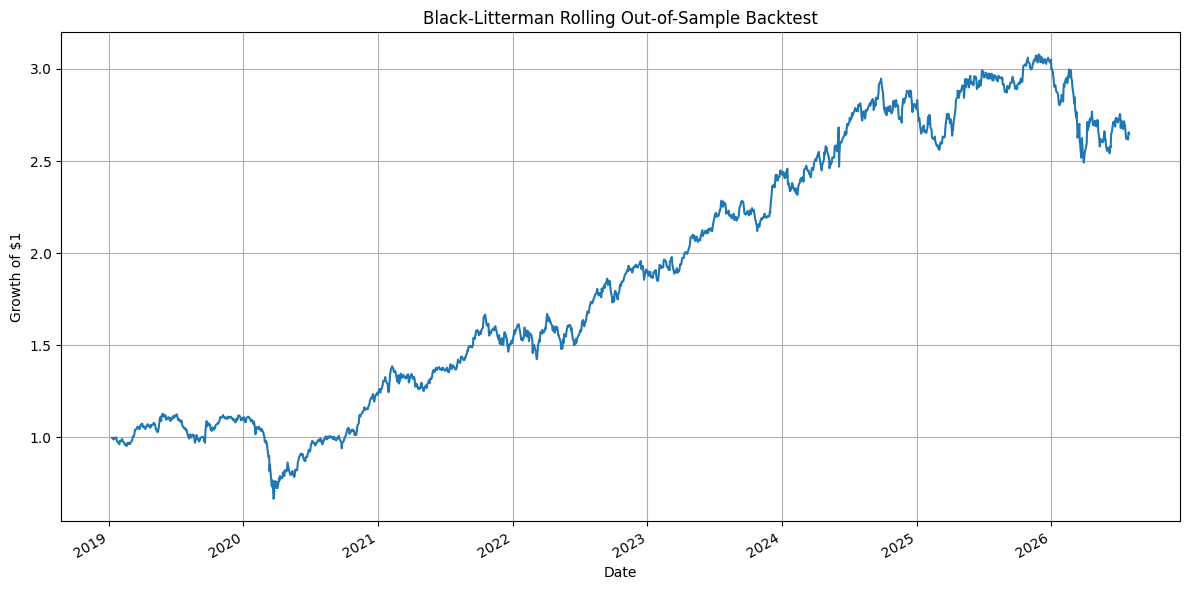

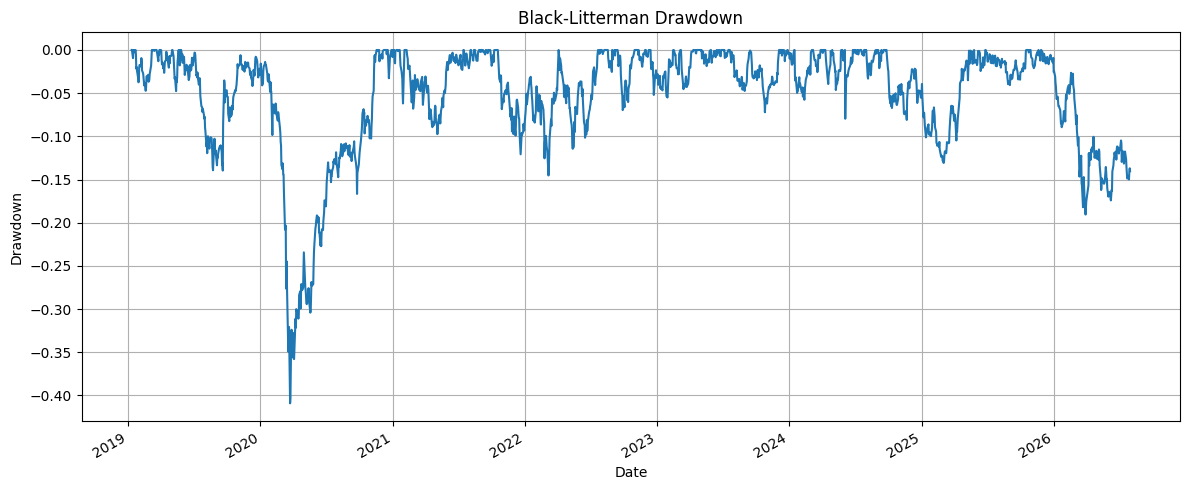

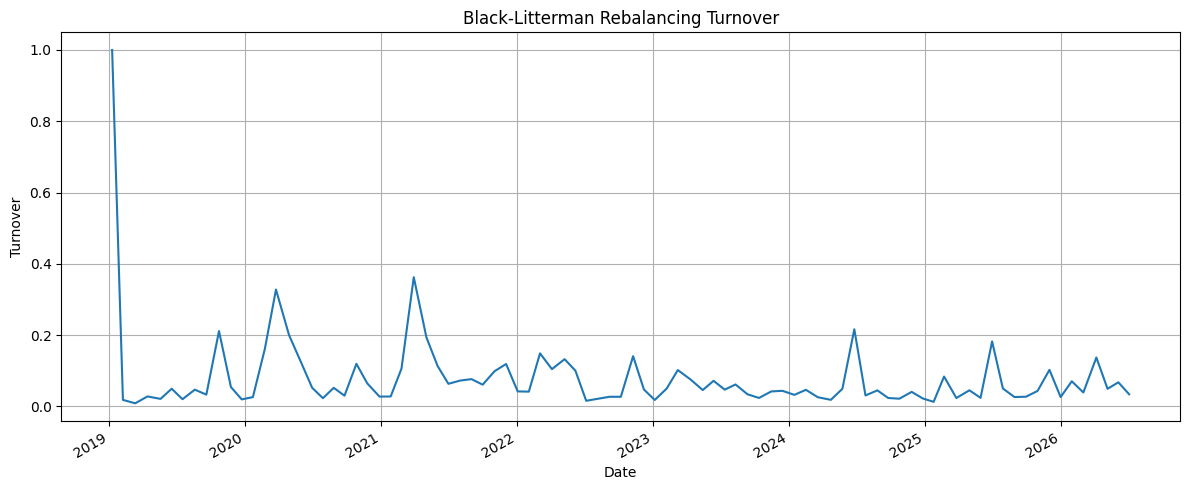

In [6]:
# ============================================================
# BLACK-LITTERMAN ROLLING OUT-OF-SAMPLE BACKTEST
# WITH TRANSACTION COSTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PARAMETERS
# ============================================================

training_window = 252
rebalance_frequency = 21

transaction_cost = 0.001     # 0.10%

delta = 2.5
tau = 0.05

risk_aversion = 2.5

max_weight = 0.30


# ============================================================
# STORAGE
# ============================================================

backtest_returns = []

weight_history = []

previous_weights = pd.Series(
    0.0,
    index=returns.columns
)


# ============================================================
# ROLLING BACKTEST
# ============================================================

for start in range(
    training_window,
    len(returns),
    rebalance_frequency
):

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train = returns.iloc[
        start - training_window:start
    ]

    assets = train.columns.tolist()

    n = len(assets)


    # --------------------------------------------------------
    # COVARIANCE MATRIX
    # --------------------------------------------------------

    Sigma = (
        train.cov() * 252
    ).values


    # --------------------------------------------------------
    # MARKET WEIGHTS
    # --------------------------------------------------------

    market_caps_train = (
        market_caps
        .reindex(assets)
        .fillna(0)
    )

    w_market = (
        market_caps_train /
        market_caps_train.sum()
    ).values.reshape(-1, 1)


    # --------------------------------------------------------
    # CURRENT VIEWS
    # --------------------------------------------------------

    Q = (
        views
        .reindex(assets)
        .values
        .reshape(-1, 1)
    )


    # --------------------------------------------------------
    # ABSOLUTE VIEW MATRIX
    # --------------------------------------------------------

    P = np.eye(n)


    # --------------------------------------------------------
    # MARKET EQUILIBRIUM RETURNS
    # --------------------------------------------------------

    pi = (
        delta *
        Sigma @
        w_market
    )


    # --------------------------------------------------------
    # VIEW UNCERTAINTY
    # --------------------------------------------------------

    Omega = np.diag(
        np.diag(
            tau *
            P @
            Sigma @
            P.T
        )
    )


    # --------------------------------------------------------
    # BLACK-LITTERMAN POSTERIOR
    # --------------------------------------------------------

    tau_sigma = (
        tau * Sigma
    )

    inv_tau_sigma = np.linalg.inv(
        tau_sigma
    )

    inv_omega = np.linalg.inv(
        Omega
    )

    posterior_cov = np.linalg.inv(
        inv_tau_sigma +
        P.T @
        inv_omega @
        P
    )

    mu_bl = (
        posterior_cov @
        (
            inv_tau_sigma @ pi +
            P.T @
            inv_omega @ Q
        )
    ).flatten()


    # --------------------------------------------------------
    # CVXPY OPTIMIZATION
    # --------------------------------------------------------

    import cvxpy as cp

    w = cp.Variable(n)

    portfolio_return = (
        mu_bl @ w
    )

    portfolio_variance = cp.quad_form(
        w,
        Sigma
    )

    objective = cp.Maximize(
        portfolio_return -
        risk_aversion *
        portfolio_variance
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight
    ]

    problem = cp.Problem(
        objective,
        constraints
    )

    problem.solve(
        solver=cp.CLARABEL
    )


    # --------------------------------------------------------
    # CHECK SOLUTION
    # --------------------------------------------------------

    if w.value is None:
        print(
            f"Optimization failed at {returns.index[start]}"
        )
        continue


    # --------------------------------------------------------
    # CURRENT WEIGHTS
    # --------------------------------------------------------

    current_weights = pd.Series(
        w.value,
        index=assets
    )

    current_weights = (
        current_weights
        .reindex(returns.columns)
        .fillna(0)
    )


    # --------------------------------------------------------
    # NORMALIZE
    # --------------------------------------------------------

    current_weights = (
        current_weights /
        current_weights.sum()
    )


    # --------------------------------------------------------
    # TURNOVER
    # --------------------------------------------------------

    turnover = (
        current_weights -
        previous_weights
    ).abs().sum()


    # --------------------------------------------------------
    # TRANSACTION COST
    # --------------------------------------------------------

    cost = (
        turnover *
        transaction_cost
    )


    # --------------------------------------------------------
    # STORE WEIGHTS
    # --------------------------------------------------------

    weight_history.append(
        pd.DataFrame(
            {
                "Weight": current_weights,
                "Turnover": turnover,
                "Transaction_Cost": cost
            }
        ).assign(
            Date=returns.index[start]
        )
    )


    # --------------------------------------------------------
    # OUT-OF-SAMPLE PERIOD
    # --------------------------------------------------------

    end = min(
        start + rebalance_frequency,
        len(returns)
    )

    test = returns.iloc[
        start:end
    ]


    # --------------------------------------------------------
    # GROSS RETURNS
    # --------------------------------------------------------

    gross_returns = (
        test @ current_weights
    )


    # --------------------------------------------------------
    # NET RETURNS
    # --------------------------------------------------------

    net_returns = (
        gross_returns.copy()
    )

    if len(net_returns) > 0:

        net_returns.iloc[0] -= cost


    # --------------------------------------------------------
    # STORE RETURNS
    # --------------------------------------------------------

    backtest_returns.append(
        net_returns
    )


    # --------------------------------------------------------
    # UPDATE PREVIOUS WEIGHTS
    # --------------------------------------------------------

    previous_weights = (
        current_weights.copy()
    )


# ============================================================
# COMBINE RETURNS
# ============================================================

backtest_returns = pd.concat(
    backtest_returns
)

backtest_returns = (
    backtest_returns[
        ~backtest_returns.index.duplicated()
    ]
)


# ============================================================
# PERFORMANCE
# ============================================================

annual_return = (
    backtest_returns.mean() *
    252
)

annual_volatility = (
    backtest_returns.std() *
    np.sqrt(252)
)

sharpe_ratio = (
    annual_return /
    annual_volatility
)


# ============================================================
# EQUITY CURVE
# ============================================================

wealth = (
    1 +
    backtest_returns
).cumprod()


# ============================================================
# DRAWDOWN
# ============================================================

running_peak = (
    wealth.cummax()
)

drawdown = (
    wealth /
    running_peak -
    1
)

maximum_drawdown = (
    drawdown.min()
)


# ============================================================
# TURNOVER
# ============================================================

weight_history_df = pd.concat(
    weight_history
)

turnover_history = (
    weight_history_df
    .groupby("Date")["Turnover"]
    .first()
)

average_turnover = (
    turnover_history.mean()
)

total_turnover = (
    turnover_history.sum()
)


# ============================================================
# TRANSACTION COST
# ============================================================

transaction_cost_history = (
    weight_history_df
    .groupby("Date")["Transaction_Cost"]
    .first()
)

total_transaction_cost = (
    transaction_cost_history.sum()
)


# ============================================================
# RESULTS
# ============================================================

print("==============================================")
print("BLACK-LITTERMAN OUT-OF-SAMPLE BACKTEST")
print("WITH TRANSACTION COSTS")
print("==============================================")

print(
    f"Annual Return         : {annual_return:.2%}"
)

print(
    f"Annual Volatility     : {annual_volatility:.2%}"
)

print(
    f"Sharpe Ratio          : {sharpe_ratio:.3f}"
)

print(
    f"Maximum Drawdown      : {maximum_drawdown:.2%}"
)

print(
    f"Average Turnover      : {average_turnover:.2%}"
)

print(
    f"Total Turnover        : {total_turnover:.2f}"
)

print(
    f"Total Transaction Cost: "
    f"{total_transaction_cost:.2%}"
)


# ============================================================
# EQUITY CURVE
# ============================================================

plt.figure(figsize=(12, 6))

wealth.plot()

plt.title(
    "Black-Litterman Rolling Out-of-Sample Backtest"
)

plt.ylabel("Growth of $1")

plt.xlabel("Date")

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# DRAWDOWN
# ============================================================

plt.figure(figsize=(12, 5))

drawdown.plot()

plt.title(
    "Black-Litterman Drawdown"
)

plt.ylabel("Drawdown")

plt.xlabel("Date")

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# TURNOVER
# ============================================================

plt.figure(figsize=(12, 5))

turnover_history.plot()

plt.title(
    "Black-Litterman Rebalancing Turnover"
)

plt.ylabel("Turnover")

plt.xlabel("Date")

plt.grid(True)

plt.tight_layout()

plt.show()